In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, LinearSVC, SVR


In [2]:
def plot_points_2d(X, y, title=""):
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=y, s=30)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_decision_boundary(model, X, y, title="", mesh_step=0.02):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, mesh_step),
        np.arange(y_min, y_max, mesh_step)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.decision_function(grid).reshape(xx.shape)

    plt.figure(figsize=(5,4))
    plt.contourf(xx, yy, (zz > 0).astype(int), alpha=0.2)
    plt.contour(xx, yy, zz, levels=[-1,0,1], linestyles=["--","-","--"])
    plt.scatter(X[:,0], X[:,1], c=y, s=30)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)
    plt.show()


## SVM lineal

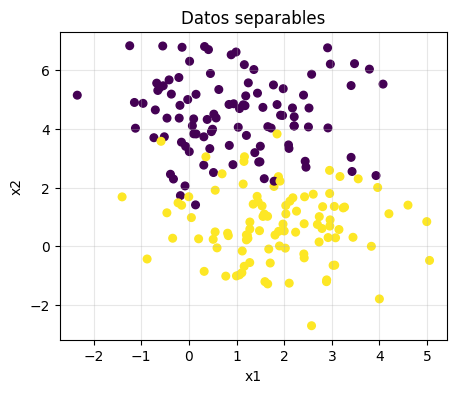

In [3]:
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.3, random_state=0)
y = np.where(y==0, -1, +1)

plot_points_2d(X, y, "Datos separables")


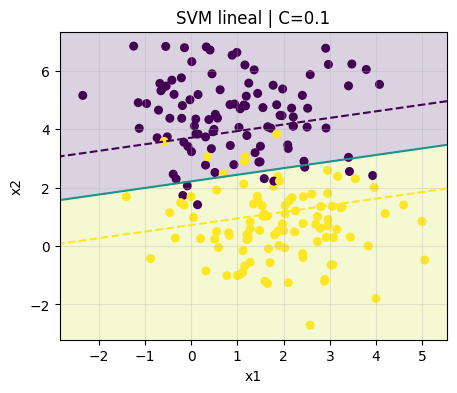

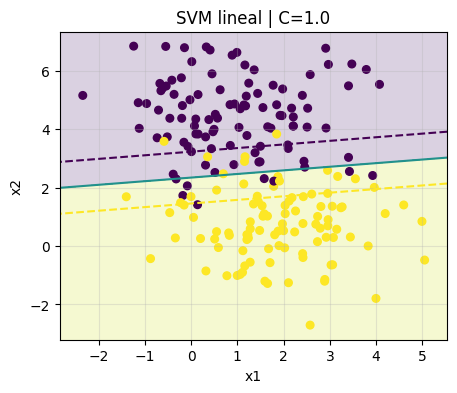

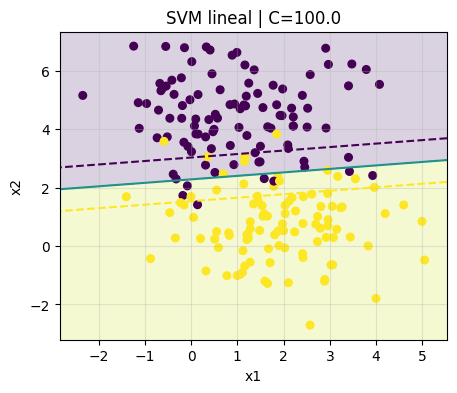

In [4]:
Cs = [0.1, 1.0, 100.0]

for C in Cs:
    model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=f"SVM lineal | C={C}")


## Kernel SVM

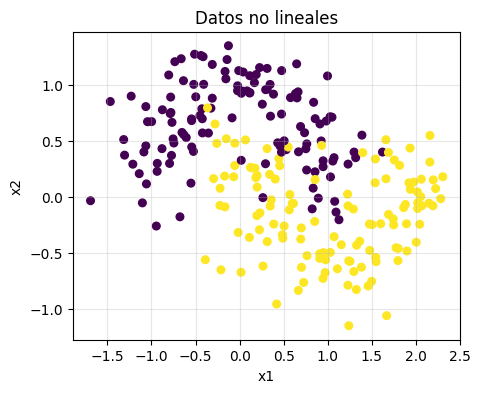

In [5]:
X, y = make_moons(n_samples=250, noise=0.25, random_state=0)
y = np.where(y==0, -1, +1)

plot_points_2d(X, y, "Datos no lineales")

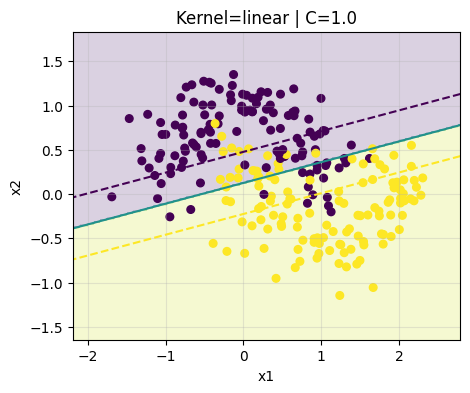

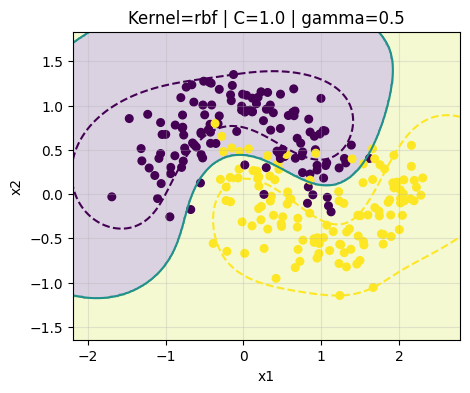

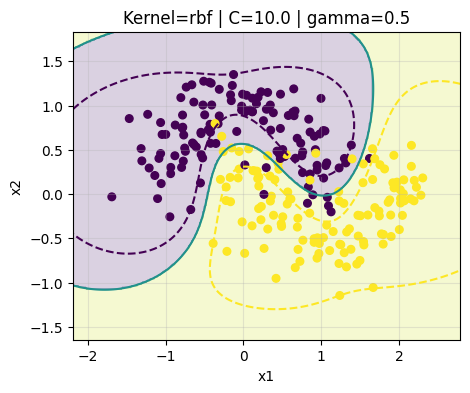

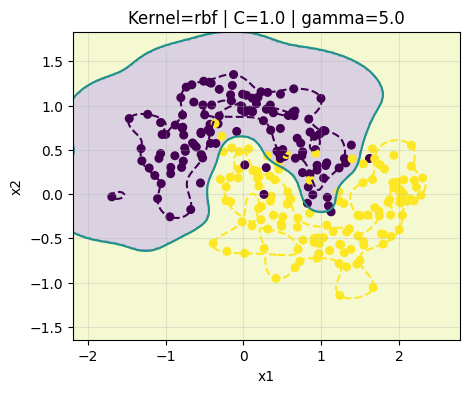

In [6]:
configs = [
    ("linear", 1.0, None),
    ("rbf", 1.0, 0.5),
    ("rbf", 10.0, 0.5),
    ("rbf", 1.0, 5.0),
]

for kernel, C, gamma in configs:
    if kernel == "linear":
        model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
        model.fit(X, y)
        plot_decision_boundary(model, X, y, title=f"Kernel={kernel} | C={C}")
    else:
        model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C, gamma=gamma))
        model.fit(X, y)
        plot_decision_boundary(model, X, y, title=f"Kernel=rbf | C={C} | gamma={gamma}")


## Hinge loss + L2 con SGD

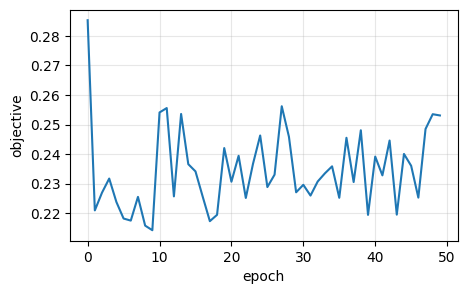

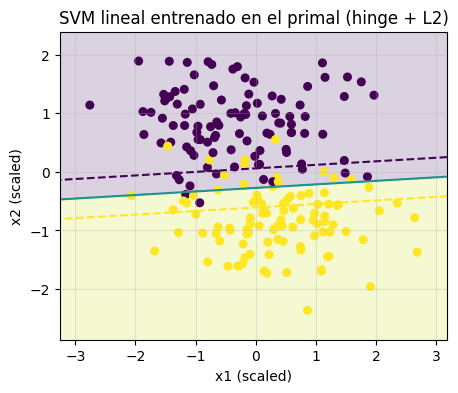

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

def hinge_loss(y, f):
    return np.maximum(0.0, 1.0 - y*f)

def train_linear_svm_hinge_sgd(X, y, lam=1e-2, lr=0.5, epochs=50, batch_size=64, seed=0):
    rng = np.random.RandomState(seed)
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []

    for ep in range(epochs):
        idx = rng.permutation(n)
        Xs = X[idx]
        ys = y[idx]

        for start in range(0, n, batch_size):
            xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size]

            f = xb @ w + b
            m = yb * f
            active = m < 1.0

            if np.any(active):
                grad_w = lam * w - (yb[active][:, None] * xb[active]).mean(axis=0)
                grad_b = - yb[active].mean()
            else:
                grad_w = lam * w
                grad_b = 0.0

            w -= lr * grad_w
            b -= lr * grad_b

        f_all = X @ w + b
        loss = (lam/2)*np.dot(w,w) + hinge_loss(y, f_all).mean()
        losses.append(loss)

    return w, b, np.array(losses)

# Dataset
X_cls, y_cls = make_blobs(n_samples=200, centers=2, cluster_std=1.3, random_state=0)
y_cls = np.where(y_cls == 0, -1, +1)

scaler_cls = StandardScaler()
Xs_cls = scaler_cls.fit_transform(X_cls)

w, b, losses = train_linear_svm_hinge_sgd(Xs_cls, y_cls, lam=1e-2, lr=0.5, epochs=50, seed=0)

plt.figure(figsize=(5,3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("objective")
plt.grid(True, alpha=0.3)
plt.show()

# Plot de frontera (2D)
xx, yy = np.meshgrid(
    np.linspace(Xs_cls[:,0].min()-0.5, Xs_cls[:,0].max()+0.5, 400),
    np.linspace(Xs_cls[:,1].min()-0.5, Xs_cls[:,1].max()+0.5, 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz = (grid @ w + b).reshape(xx.shape)

plt.figure(figsize=(5,4))
plt.contourf(xx, yy, (zz>0).astype(int), alpha=0.2)
plt.contour(xx, yy, zz, levels=[-1,0,1], linestyles=["--","-","--"])
plt.scatter(Xs_cls[:,0], Xs_cls[:,1], c=y_cls, s=30)
plt.title("SVM lineal entrenado en el primal (hinge + L2)")
plt.xlabel("x1 (scaled)")
plt.ylabel("x2 (scaled)")
plt.grid(True, alpha=0.3)
plt.show()


# Practica

In [8]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

NameError: name 'train_test_split' is not defined

# SVR

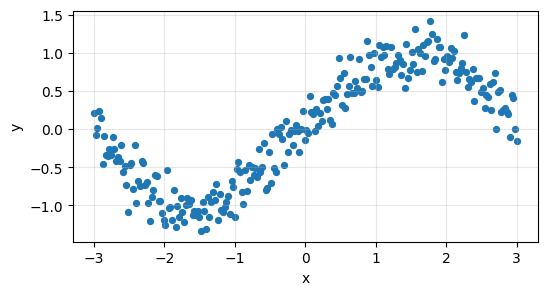

In [9]:
rng = np.random.RandomState(0)
X = np.linspace(-3, 3, 250)[:, None]
y = np.sin(X).ravel() + 0.2*rng.randn(X.shape[0])

plt.figure(figsize=(6,3))
plt.scatter(X[:,0], y, s=18)
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()


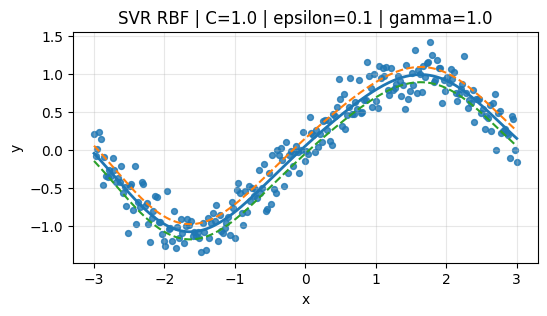

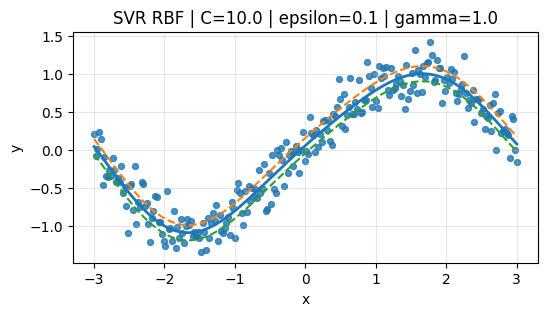

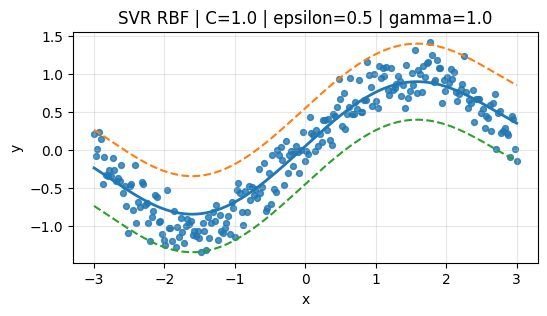

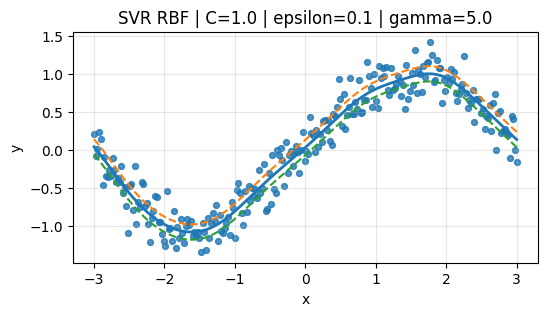

In [10]:
def plot_svr_fit(X, y, model, title=""):
    model.fit(X, y)
    xs = np.linspace(X.min(), X.max(), 400)[:,None]
    yp = model.predict(xs)

    plt.figure(figsize=(6,3))
    plt.scatter(X[:,0], y, s=18, alpha=0.8)
    plt.plot(xs[:,0], yp, linewidth=2)

    eps = model.named_steps["svr"].epsilon if hasattr(model, "named_steps") else model.epsilon
    plt.plot(xs[:,0], yp + eps, linestyle="--")
    plt.plot(xs[:,0], yp - eps, linestyle="--")

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.show()

configs = [
    (1.0, 0.1, 1.0),
    (10.0, 0.1, 1.0),
    (1.0, 0.5, 1.0),
    (1.0, 0.1, 5.0),
]

for C, eps, gamma in configs:
    model = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=C, epsilon=eps, gamma=gamma))
    plot_svr_fit(X, y, model, title=f"SVR RBF | C={C} | epsilon={eps} | gamma={gamma}")
